Hand-drawn Circuit Component Recognition <br>
Author: Apurva Umredkar<br><br>
Step 4: Deploying the trained classifier for real-time circuit component recognition

In [1]:
from CktComponentRecognizer import * 
import cv2 
from matplotlib import pyplot as plt 
import numpy as np
from time import sleep 
from IPython.display import  clear_output


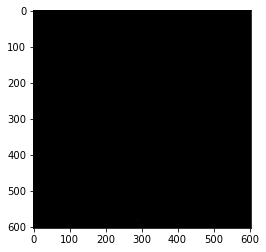

In [2]:
def full_recognize(img_path, block_size = None):
    ckt = cv2.imread(img_path)
    ckt = thresholdImage(ckt)
    plt.imshow(ckt)
    plt.title("Input Image of circuit")
    plt.show()

    # calculate the black percent of thresholded image 
    ckt_bw = cv2.cvtColor(ckt, cv2.COLOR_BGR2GRAY)/255
    count_black = np.sum((ckt_bw == 0)*1)
    black_percent = 100 * count_black / (ckt_bw.shape[0]*ckt_bw.shape[1])
    print(f"Black % in input ckt image: {black_percent}")

    #  running segmentation
    x, y = ckt_bw.shape
    block_size = y//5
    stride = (x//30, y//30)
    for i in range(0, x, stride[0]):
        if i < x - block_size:
            for j in range(0, y, stride[1]):
                if j < y - block_size:
                    ckt_block = ckt[i:i+block_size, j:j+block_size, :]
                    
                    # calculating the black percent of the block
                    ckt_block_bw = cv2.cvtColor(ckt_block, cv2.COLOR_BGR2GRAY)
                    block_count_black = np.sum((ckt_block_bw == 0)*1)
                    block_black_percent = 100 * block_count_black / (ckt_block_bw.shape[0]*ckt_block_bw.shape[1])

                    if block_black_percent < black_percent:
                        print(recognize_component(ckt_block))

                    plt.imshow(ckt_block)
                    plt.show()
                    clear_output(wait=True)

    
    


full_recognize(r"D:\VNIT ECE\ECE 8th Sem\ML\PROJECT\test images\oscillator.jpg")